# NBA Fantasy Point Prediction — Results

This notebook runs the full project pipeline and presents the analysis and results.
All code lives in `src/` — this notebook only calls functions from those files.

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), 'src'))

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from config import DATA_DIR, RESULTS_DIR, FANTASY_SCORING
from load import get_all_players_game_logs, get_bball_ref_all_seasons, get_sleeper_data
from features import build_features
from model import train_and_evaluate

DATA_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

## Step 1 — Data Collection

Fetch game logs for all active NBA players across the 2024-25 and 2025-26 seasons.
Results are cached to `data/game_logs/` so re-runs skip already-fetched players.

In [2]:
game_logs = get_all_players_game_logs(DATA_DIR)
print(f"Game logs: {len(game_logs):,} rows | {game_logs['PLAYER_ID'].nunique()} players")

--- Fetching game logs for 530 active players ---
[530/530] Skipped (cached): 524 players so far...ching: Nikola Đurišić                 
Combining 524 player files...
Saved combined game logs to /Users/danny/Coding/dsci510_spring2026_final_project/data/game_logs_all.csv (48874 rows, 524 players)

--- 6 player(s) had no game log data ---

Reason: No game logs returned for either season
  - Tamar Bates
  - Kevon Harris
  - Eli John Ndiaye
  - Thomas Sorber
  - Alex Toohey
  - Nikola Đurišić

Summary: 524/530 players have game log data.
Game logs: 48,874 rows | 524 players


## Step 2 — Team Advanced Stats

Scrape Basketball Reference for team-level ORtg, DRtg, and Pace for both seasons.
Team names are normalized to match nba_api abbreviations using a manual mapping.

In [3]:
team_stats = get_bball_ref_all_seasons()
team_stats.to_csv(DATA_DIR / 'team_stats.csv', index=False)
team_stats[['Team', 'TEAM_ABB', 'SEASON', 'ORtg', 'DRtg', 'Pace']].head(10)

--- Fetching Basketball Reference Team Stats (2025) ---
Success! Found 30 teams.
--- Fetching Basketball Reference Team Stats (2026) ---
Success! Found 30 teams.


,Team,TEAM_ABB,SEASON,ORtg,DRtg,Pace
0,Oklahoma City Thunder,OKC,2024-25,120.3,107.5,100.0
1,Boston Celtics,BOS,2024-25,120.6,111.1,95.7
2,Cleveland Cavaliers,CLE,2024-25,121.7,112.2,99.8
3,Minnesota Timberwolves,MIN,2024-25,116.6,111.5,97.3
4,Los Angeles Clippers,LAC,2024-25,115.1,110.3,97.5
5,Memphis Grizzlies,MEM,2024-25,117.7,113.0,103.3
6,Houston Rockets,HOU,2024-25,115.3,110.8,98.6
7,New York Knicks,NYK,2024-25,118.5,114.3,96.7
8,Denver Nuggets,DEN,2024-25,119.9,116.0,99.8
9,Golden State Warriors,GSW,2024-25,115.0,111.7,98.7


## Step 3 — Feature Engineering

Build the feature matrix:
- Fantasy points calculated per game using the project scoring system
- Exponentially Weighted Moving Averages (EWMA, span=5 and span=10) for all major stats, shifted by 1 game to prevent data leakage. EWMA gives more weight to recent games than a simple rolling average.
- Back-to-back game flag (`IS_B2B`) — 1 when the player played the previous night
- Opponent DRtg and Pace joined from Basketball Reference
- Own team ORtg joined from Basketball Reference
- Home/away indicator parsed from MATCHUP column
- Binary injury flag from Sleeper API

In [4]:
injuries = get_sleeper_data()
features = build_features(DATA_DIR, injuries_df=injuries)
print(f"Feature matrix: {features.shape[0]:,} rows x {features.shape[1]} columns")
features[['PLAYER_NAME', 'GAME_DATE', 'FANTASY_PTS', 'FANTASY_PTS_EWMA5', 'FANTASY_PTS_EWMA10', 'OPP_DRTG', 'IS_HOME', 'IS_INJURED']].head(10)

--- Requesting Sleeper NBA Data ---
--- Load Complete: 121 Injured Players Found ---
Computing EWMA features...
Injury flag set: 10720 game rows flagged.
Features saved to /Users/danny/Coding/dsci510_spring2026_final_project/data/features.csv (48874 rows, 524 players)
Feature matrix: 48,874 rows x 58 columns


,PLAYER_NAME,GAME_DATE,FANTASY_PTS,FANTASY_PTS_EWMA5,FANTASY_PTS_EWMA10,OPP_DRTG,IS_HOME,IS_INJURED
0,LeBron James,2024-10-22,32.5,NaN,NaN,111.5,1,0
1,LeBron James,2024-10-25,36.8,32.500000,32.500000,119.3,1,0
2,LeBron James,2024-10-26,63.8,35.080000,34.865000,116.2,1,0
3,LeBron James,2024-10-28,31.0,48.684211,46.496678,119.3,0,0
4,LeBron James,2024-10-30,32.2,41.338462,41.391213,112.2,0,0
5,LeBron James,2024-11-01,54.7,37.830332,38.752666,114.8,0,0
6,LeBron James,2024-11-04,51.6,43.994737,42.894739,113.1,0,0
7,LeBron James,2024-11-06,57.4,46.687421,44.992357,113.0,0,0
8,LeBron James,2024-11-08,62.9,50.403267,47.815156,118.2,1,0
9,LeBron James,2024-11-10,55.0,54.680095,51.097090,114.8,1,0


### Fantasy Points Distribution

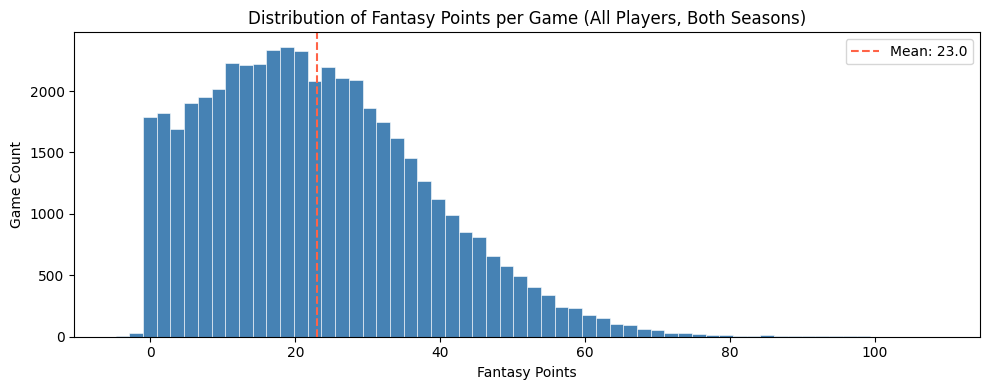

In [5]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(features['FANTASY_PTS'], bins=60, color='steelblue', edgecolor='white', linewidth=0.4)
ax.axvline(features['FANTASY_PTS'].mean(), color='tomato', linestyle='--', label=f"Mean: {features['FANTASY_PTS'].mean():.1f}")
ax.set_xlabel('Fantasy Points')
ax.set_ylabel('Game Count')
ax.set_title('Distribution of Fantasy Points per Game (All Players, Both Seasons)')
ax.legend()
plt.tight_layout()
plt.show()

### Train / Test Split

Models are trained on the 2024-25 season and tested on the 2025-26 season.
This time-based split reflects how the model would be used in practice.

In [6]:
train = features[features['SEASON'] == '2024-25']
test  = features[features['SEASON'] == '2025-26']
print(f"Train (2024-25): {len(train):,} rows")
print(f"Test  (2025-26): {len(test):,} rows")

Train (2024-25): 23,294 rows
Test  (2025-26): 25,580 rows


## Step 4 — Model Training & Evaluation

Four models are trained and evaluated:
1. **Linear Regression (Baseline)** — EWMA player stats only
2. **Linear Regression (Full)** — EWMA stats + opponent DRtg, pace, own ORtg, home/away, injury, back-to-back flag
3. **Random Forest (Full)** — same full feature set
4. **XGBoost (Full)** — same full feature set (advanced model)

Train: 2024-25 season | Test: 2025-26 season (time-based split).
Metric: RMSE (lower is better). Also evaluated with 5-fold cross-validation.

In [7]:
results = train_and_evaluate(DATA_DIR, RESULTS_DIR)
results

Train: 23294 rows | Test: 25580 rows

Training Linear Regression (Baseline)...
  Test RMSE:  10.177
  CV RMSE:    10.400 (+/- 0.400)

Training Linear Regression (Full)...
  Test RMSE:  10.146
  CV RMSE:    10.359 (+/- 0.398)

Training Random Forest (Full)...
  Test RMSE:  10.350
  CV RMSE:    10.621 (+/- 0.471)

Training XGBoost (Full)...
  Test RMSE:  10.209
  CV RMSE:    10.525 (+/- 0.414)

--- Model Comparison ---
            Model Features  Test RMSE  CV RMSE (mean)  CV RMSE (std)
Linear Regression Baseline     10.177          10.400          0.400
Linear Regression     Full     10.146          10.359          0.398
    Random Forest     Full     10.350          10.621          0.471
          XGBoost     Full     10.209          10.525          0.414


,Model,Features,Test RMSE,CV RMSE (mean),CV RMSE (std),Train rows,Test rows
0,Linear Regression,Baseline,10.177,10.400,0.400,22852,25498
1,Linear Regression,Full,10.146,10.359,0.398,22852,25498
2,Random Forest,Full,10.350,10.621,0.471,22852,25498
3,XGBoost,Full,10.209,10.525,0.414,22852,25498


### Model Comparison — Test RMSE

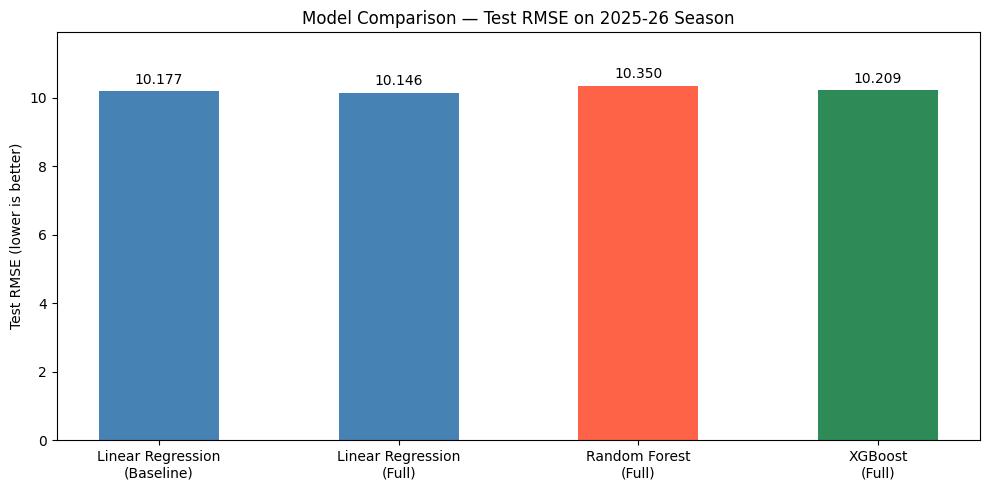

In [8]:
labels = results['Model'] + '\n(' + results['Features'] + ')'
rmse_values = results['Test RMSE']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, rmse_values, color=['steelblue', 'steelblue', 'tomato', 'seagreen'], width=0.5)
ax.bar_label(bars, fmt='%.3f', padding=3)
ax.set_ylabel('Test RMSE (lower is better)')
ax.set_title('Model Comparison — Test RMSE on 2025-26 Season')
ax.set_ylim(0, rmse_values.max() * 1.15)
plt.tight_layout()
plt.show()

### Predicted vs Actual Fantasy Points (Best Model)

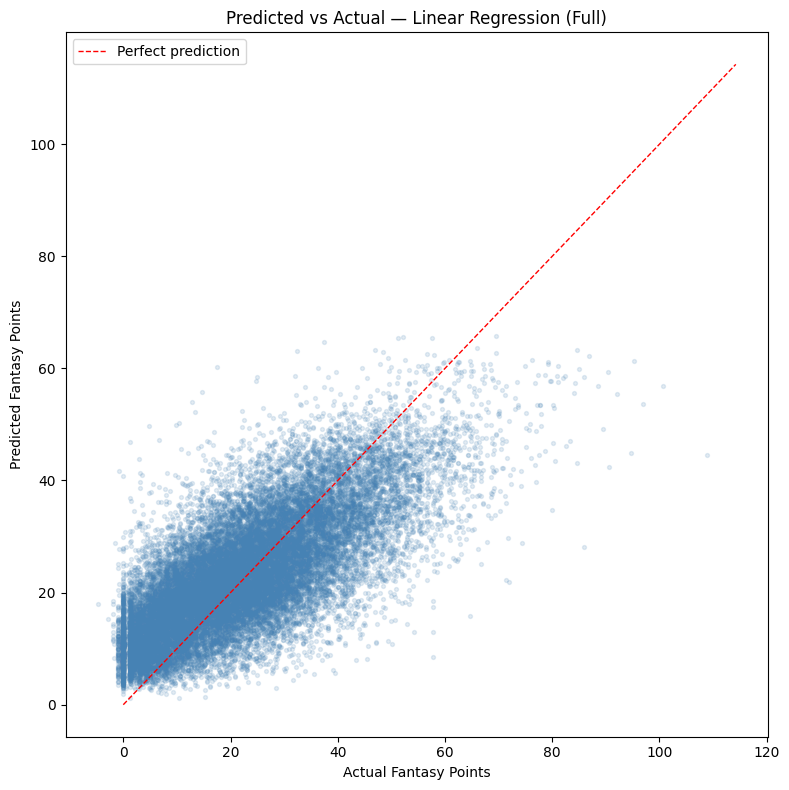

In [9]:
# Load predictions from the best performing model
best_model_row = results.loc[results['Test RMSE'].idxmin()]
model_label = best_model_row['Model'].lower().replace(' ', '_')
feature_label = best_model_row['Features'].lower()
pred_file = RESULTS_DIR / f'predictions_{model_label}_{feature_label}.csv'

preds_df = pd.read_csv(pred_file)

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(preds_df['FANTASY_PTS'], preds_df['PREDICTED'], alpha=0.15, s=8, color='steelblue')
lims = [0, preds_df['FANTASY_PTS'].max() * 1.05]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlabel('Actual Fantasy Points')
ax.set_ylabel('Predicted Fantasy Points')
ax.set_title(f'Predicted vs Actual — {best_model_row["Model"]} ({best_model_row["Features"]})')
ax.legend()
plt.tight_layout()
plt.show()

## Summary

**Key findings:**

- Exponentially Weighted Moving Averages (EWMA) of recent player performance are the dominant predictors of fantasy points. EWMA outperformed simple rolling averages across all models by capturing recency bias more accurately.
- Contextual features (opponent DRtg, pace, home/away, injury status, own ORtg, back-to-back flag) add a modest improvement (~0.04 RMSE) on top of EWMA features alone.
- **Linear Regression Full achieved the best test RMSE (10.146)**, outperforming Random Forest (10.350) and XGBoost (10.209) — suggesting the relationships in the data are mostly linear.
- An RMSE of ~10 on a mean fantasy score of 23 points reflects the inherent noise in individual game performance. Foul trouble, matchup variance, and minutes changes cannot be predicted from box score history alone.